In [77]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### 1. Load the dataset

In [78]:
df = pd.read_csv('../data/emails.csv')
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB


In [80]:
df.isna().sum()

text    0
spam    0
dtype: int64

### 2. Data Cleaning 

#### 1. convert lowercase

In [81]:
def convert_lowercase(text : str) -> str:
    return text.lower()

In [82]:
df['text'] = df['text'].apply(convert_lowercase)

#### 2. remove spcial character / punctuation

In [83]:
def remove_punctuation(text: str) -> str:
    cleaned = ''.join(c if c.isalnum() else ' ' for c in text)
    return ' '.join(cleaned.split())

In [84]:
df['text'] = df['text'].apply(remove_punctuation)

#### 3.stopwords remove

In [85]:
import nltk
from nltk.corpus import stopwords

In [86]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [87]:
stopword = set(stopwords.words('english'))
def remove_stopwords(text: str) -> list[str]:
    x = []
    for word in text.split():
        if word not in stopword:
            x.append(word)
    y = x[:]
    x.clear()
    return y


In [88]:
df['text'] = df['text'].apply(remove_stopwords)

In [89]:
df.head()

,text,spam
0,"[subject, naturally, irresistible, corporate, ...",1
1,"[subject, stock, trading, gunslinger, fanny, m...",1
2,"[subject, unbelievable, new, homes, made, easy...",1
3,"[subject, 4, color, printing, special, request...",1
4,"[subject, money, get, software, cds, software,...",1


#### 4. perform stemming removes the similar word

In [90]:
import nltk.stem.porter as porter
stemmer = porter.PorterStemmer()

In [91]:
y = []
def stem_words(text: list[str]) -> list[str]:
    for word in text:
        y.append(stemmer.stem(word))
    z = y[:]
    y.clear()
    return z

In [92]:
df['text'] = df['text'].apply(stem_words)

#### 5. join word and convert to string

In [94]:
def join_words(text: list[str]) -> str:
    return ' '.join(text)

In [95]:
df['text'] = df['text'].apply(join_words)

### 3. CountVectorizer / TF-IDF

In [97]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

In [110]:
## apply the vectorizer to the text data and convert it to an array
X = vectorizer.fit_transform(df['text']).toarray()
y = df['spam'].values

### 4. train test split

In [111]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 5. Naive Bayes / Logistic Regression

#### 1.Naive Bayes

In [127]:
from sklearn.naive_bayes import MultinomialNB,BernoulliNB,GaussianNB
model1 = MultinomialNB()
model2 = BernoulliNB()
model3 = GaussianNB()


In [128]:
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [129]:
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)

In [131]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,precision_score, recall_score

####  2. Evaluation (Accuracy, Precision, Recall, F1) for Naive Bayes 

In [130]:
print("multinomialNB accuracy: ", accuracy_score(y_test, y_pred1))
print("BernoulliNB accuracy: ", accuracy_score(y_test, y_pred2))
print("GaussianNB accuracy: ", accuracy_score(y_test, y_pred3))

multinomialNB accuracy:  0.9895287958115183
BernoulliNB accuracy:  0.9808027923211169
GaussianNB accuracy:  0.9537521815008726


              precision    recall  f1-score   support

           0       1.00      0.99      0.99       856
           1       0.97      0.99      0.98       290

    accuracy                           0.99      1146
   macro avg       0.98      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



<Axes: >

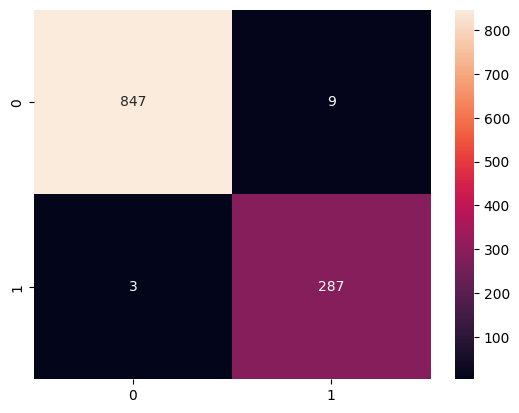

In [132]:
print(classification_report(y_test, y_pred1))   
sns.heatmap(confusion_matrix(y_test, y_pred1), annot=True, fmt='d')

#### 3. Logistic Regression

In [133]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [134]:
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [135]:
y_pred = lr.predict(X_test)

#### 4. Evaluation (Accuracy, Precision, Recall, F1) for LogisticRegression

In [137]:
print("LogisticRegression accuracy score : ",accuracy_score(y_test, y_pred))

LogisticRegression accuracy score :  0.9912739965095986


In [139]:
y_p1 = lr.predict(X_train)
y_p2 = lr.predict(X_test)

In [141]:
print("y_p1 train data accuracy score : ",accuracy_score(y_train, y_p1))
print("y_p2 test data accuracy score : ",accuracy_score(y_test, y_p2))

y_p1 train data accuracy score :  1.0
y_p2 test data accuracy score :  0.9912739965095986


In [143]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       856
           1       0.99      0.98      0.98       290

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146

